# 2. Data Exploration & Quality Analysis

## 2.1 Dataset Import & Initial Inspection
In this section, we load the raw dataset and inspect its structure, data types, and initial records to verify data integrity.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')

# Display dataset dimensions and first 5 rows
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Dimensions: 12330 rows, 18 columns



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.2 Data Structure & Quality Audit
We evaluate column data types, verify missing values, detect duplicated session records, and check target variable distribution to determine necessary preprocessing steps.

In [12]:
# Check data summary, missing values, and duplicate rows
print(f"Total Duplicate Rows: {df.duplicated().sum()}\n")

print("Missing Values per Column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values detected across all columns!\n")

# Target Distribution (Revenue)
revenue_summary = pd.DataFrame({
    'Count': df['Revenue'].value_counts(),
    'Percentage (%)': (df['Revenue'].value_counts(normalize=True) * 100).round(2)
})
print("--- Target Distribution (Revenue) ---")
print(revenue_summary)

Total Duplicate Rows: 125

Missing Values per Column:
No missing values detected across all columns!

--- Target Distribution (Revenue) ---
         Count  Percentage (%)
Revenue                       
False    10422           84.53
True      1908           15.47


## 2.3 Visualizing Target Class Imbalance
We plot the distribution of the target variable `Revenue` to visually demonstrate the ratio between converting and non-converting user sessions.

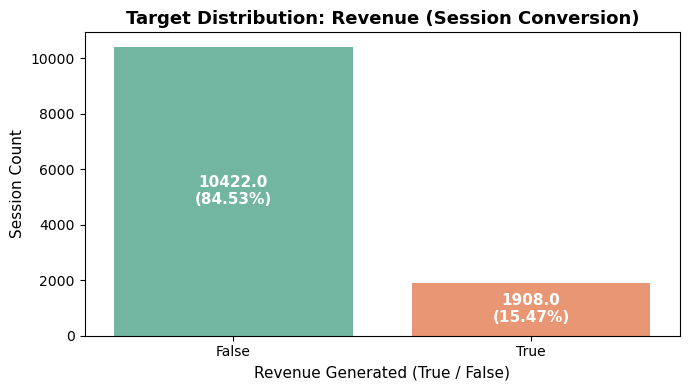

In [13]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Revenue', hue='Revenue', data=df, palette='Set2', legend=False)
plt.title('Target Distribution: Revenue (Session Conversion)', fontsize=13, fontweight='bold')
plt.xlabel('Revenue Generated (True / False)', fontsize=11)
plt.ylabel('Session Count', fontsize=11)

# Annotate count and percentage inside each bar
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(100 * height / total):.2f}%'
    ax.annotate(f'{height}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.4 Statistical Summary of Continuous Numerical Features
We evaluate the central tendencies, spread, and extremes across user browsing duration, bounce rates, exit rates, and page values to spot skewness and outliers.

In [14]:
# Select continuous session metrics
num_cols = [
    'Administrative_Duration', 'Informational_Duration', 
    'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
    'PageValues', 'SpecialDay'
]

# Transpose output for readability and display key metrics
num_summary = df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
num_summary.columns = ['Mean', 'Std Dev', 'Min', 'Median (50%)', 'Max']
display(num_summary)

,Mean,Std Dev,Min,Median (50%),Max
Administrative_Duration,80.818611,176.779107,0.0,7.500000,3398.750000
Informational_Duration,34.472398,140.749294,0.0,0.000000,2549.375000
ProductRelated_Duration,1194.746220,1913.669288,0.0,598.936905,63973.522230
BounceRates,0.022191,0.048488,0.0,0.003112,0.200000
ExitRates,0.043073,0.048597,0.0,0.025156,0.200000
PageValues,5.889258,18.568437,0.0,0.000000,361.763742
SpecialDay,0.061427,0.198917,0.0,0.000000,1.000000


## 2.5 Continuous Feature Distributions vs. Revenue
We plot boxplots for key continuous metrics (`PageValues`, `ExitRates`, `ProductRelated_Duration`) segmented by conversion status to observe feature separation.

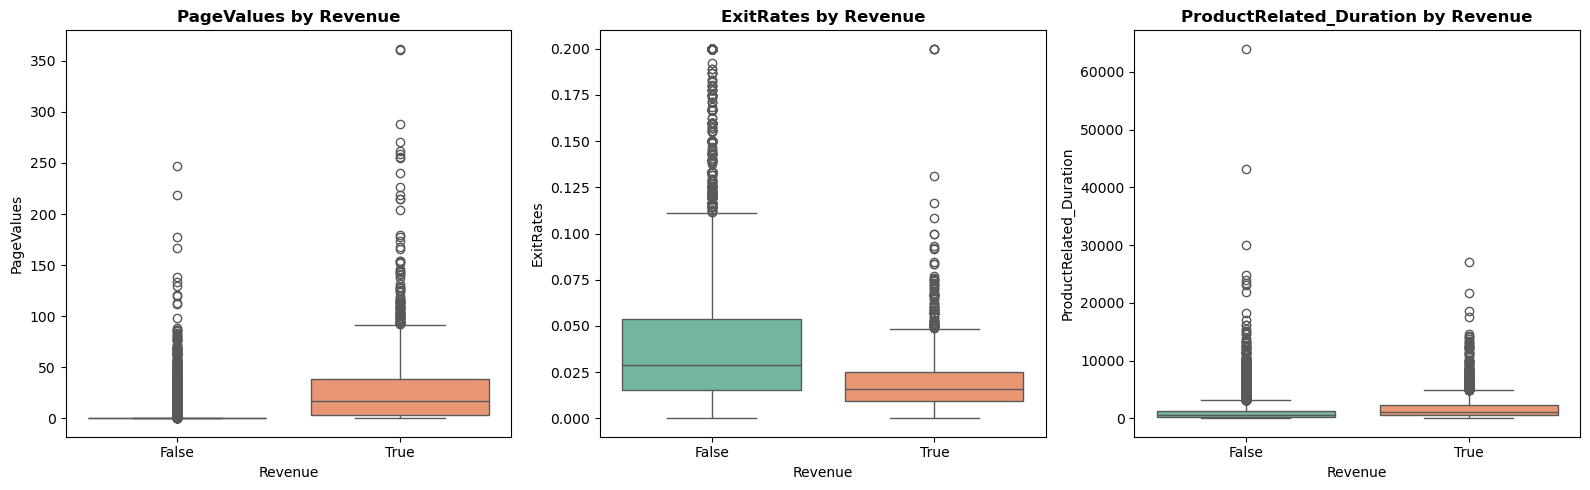

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PageValues vs Revenue
sns.boxplot(x='Revenue', y='PageValues', hue='Revenue', data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('PageValues by Revenue', fontweight='bold')

# ExitRates vs Revenue
sns.boxplot(x='Revenue', y='ExitRates', hue='Revenue', data=df, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('ExitRates by Revenue', fontweight='bold')

# ProductRelated_Duration vs Revenue
sns.boxplot(x='Revenue', y='ProductRelated_Duration', hue='Revenue', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('ProductRelated_Duration by Revenue', fontweight='bold')

plt.tight_layout()
plt.show()